# Titanic Neural Network

## Import

In [1]:
import torch
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

## Load data

In [2]:
titanic_data = pd.read_csv('titanic.csv')
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Drop unnecessary columns

In [4]:
titanic_data = titanic_data.drop(['Name', 'Ticket', 'SibSp', 'Cabin', 'Parch', 'PassengerId'], axis=1)
titanic_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


### Convert Sex column

In [5]:
titanic_data['Sex'] = (titanic_data['Sex'] == 'male').astype(np.float32)
titanic_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,1.0,22.0,7.2500,S
1,1,1,0.0,38.0,71.2833,C
2,1,3,0.0,26.0,7.9250,S
3,1,1,0.0,35.0,53.1000,S
4,0,3,1.0,35.0,8.0500,S


### Convert Class column to 3 other

In [6]:
titanic_data['Upper_class'] = (titanic_data['Pclass'] == 1).astype(np.float32)
titanic_data['Middle_class'] = (titanic_data['Pclass'] == 2).astype(np.float32)
titanic_data['Lower_class'] = (titanic_data['Pclass'] == 3).astype(np.float32)

### Convert Embarked column to 3 other

In [7]:
titanic_data['Cherbourg_port'] = (titanic_data['Embarked'] == 'C').astype(np.float32)
titanic_data['Quenstown_port'] = (titanic_data['Embarked'] == 'Q').astype(np.float32)
titanic_data['Southampton_port'] = (titanic_data['Embarked'] == 'S').astype(np.float32)
titanic_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Upper_class,Middle_class,Lower_class,Cherbourg_port,Quenstown_port,Southampton_port
0,0,3,1.0,22.0,7.2500,S,0.0,0.0,1.0,0.0,0.0,1.0
1,1,1,0.0,38.0,71.2833,C,1.0,0.0,0.0,1.0,0.0,0.0
2,1,3,0.0,26.0,7.9250,S,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,0.0,35.0,53.1000,S,1.0,0.0,0.0,0.0,0.0,1.0
4,0,3,1.0,35.0,8.0500,S,0.0,0.0,1.0,0.0,0.0,1.0


### Fill missing age values with the average value of the values

In [8]:
age = np.array(titanic_data['Age'])
age_mean = age[~np.isnan(age)].mean()
age[np.isnan(age)] = age_mean
titanic_data['Age'] = age
titanic_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Upper_class,Middle_class,Lower_class,Cherbourg_port,Quenstown_port,Southampton_port
0,0,3,1.0,22.0,7.2500,S,0.0,0.0,1.0,0.0,0.0,1.0
1,1,1,0.0,38.0,71.2833,C,1.0,0.0,0.0,1.0,0.0,0.0
2,1,3,0.0,26.0,7.9250,S,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,0.0,35.0,53.1000,S,1.0,0.0,0.0,0.0,0.0,1.0
4,0,3,1.0,35.0,8.0500,S,0.0,0.0,1.0,0.0,0.0,1.0


### Drop additional columns after calculation

In [9]:
titanic_data = titanic_data.drop(['Embarked', 'Pclass'], axis=1)
titanic_data.head()

,Survived,Sex,Age,Fare,Upper_class,Middle_class,Lower_class,Cherbourg_port,Quenstown_port,Southampton_port
0,0,1.0,22.0,7.2500,0.0,0.0,1.0,0.0,0.0,1.0
1,1,0.0,38.0,71.2833,1.0,0.0,0.0,1.0,0.0,0.0
2,1,0.0,26.0,7.9250,0.0,0.0,1.0,0.0,0.0,1.0
3,1,0.0,35.0,53.1000,1.0,0.0,0.0,0.0,0.0,1.0
4,0,1.0,35.0,8.0500,0.0,0.0,1.0,0.0,0.0,1.0


## Display heatmap about correlation

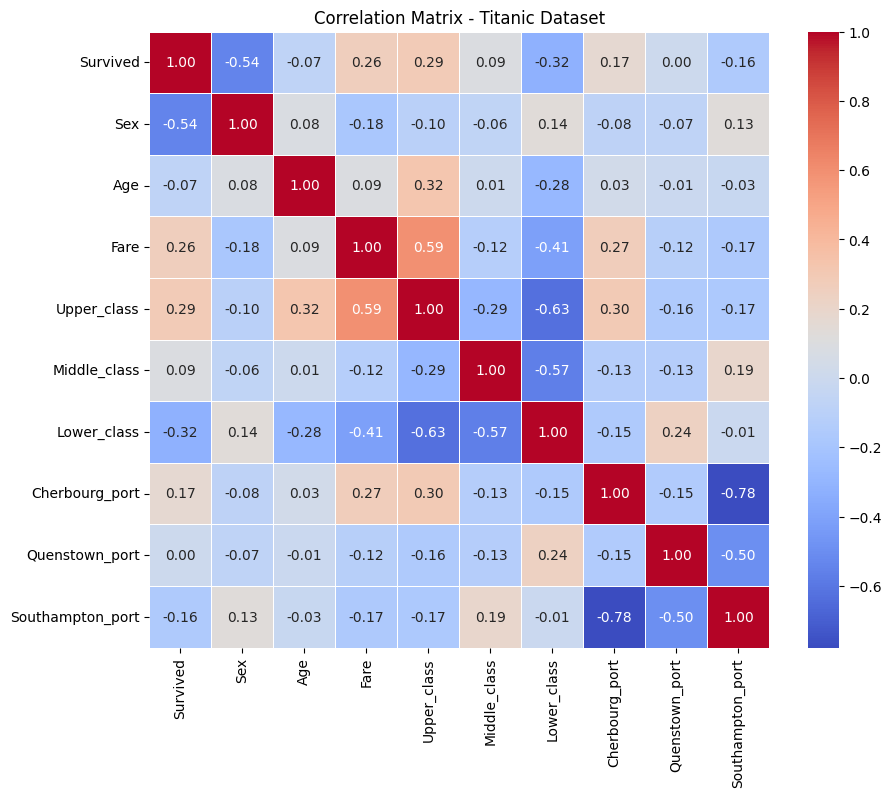

In [10]:
correlation_matrix = titanic_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix - Titanic Dataset')
plt.show()

## Display survived and not survived columns

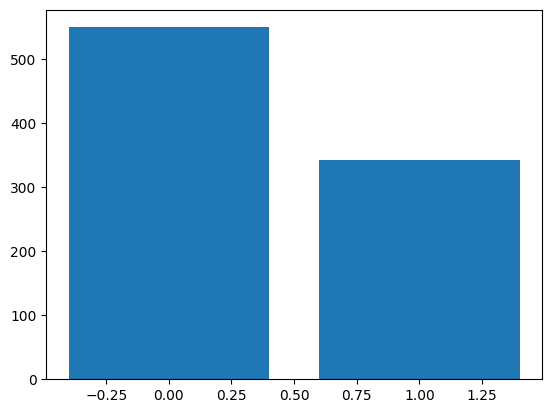

In [11]:
survived_ids, survided_count = np.unique(titanic_data['Survived'], return_counts=True)
plt.bar(survived_ids, survided_count)
plt.show()

## Display histograms about Sex, Age and Survived connections

C:\Users\karcagtamas\AppData\Local\Temp\ipykernel_22768\1739114411.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


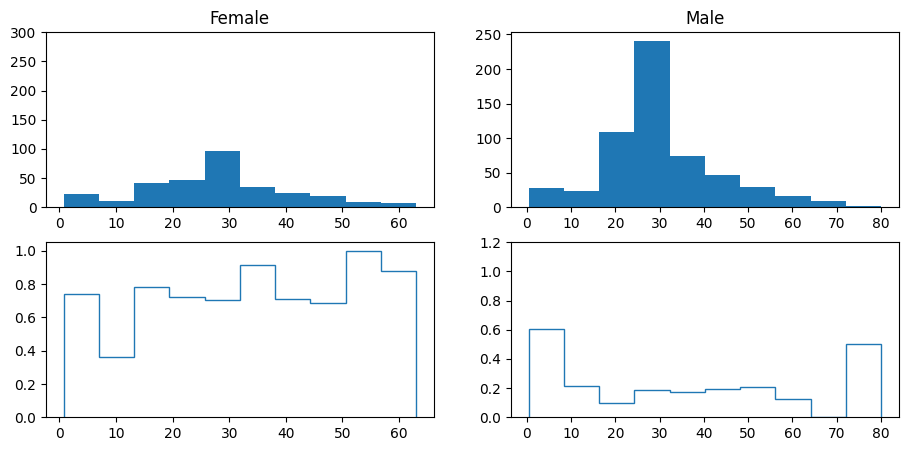

In [12]:
figure, axes = plt.subplots(2, 2, sharey=False, figsize=(11,5))
counts, bins = np.histogram(titanic_data['Age'][titanic_data['Sex'] == 0])
axes[0, 0].stairs(counts, bins, fill=True)
axes[0, 0].set_title('Female')

sum_survived, _ = np.histogram(titanic_data['Age'][titanic_data['Sex'] == 0], bins, weights=titanic_data['Survived'][titanic_data['Sex'] == 0])
survived_ratio = sum_survived / counts
axes[1, 0].stairs(survived_ratio, bins)

counts, bins = np.histogram(titanic_data['Age'][titanic_data['Sex'] == 1])
axes[0, 1].stairs(counts, bins, fill=True)
axes[0, 1].set_title('Male')
axes[0, 0].set_yticks(axes[0, 1].get_yticks())

sum_survived, _ = np.histogram(titanic_data['Age'][titanic_data['Sex'] == 1], bins, weights=titanic_data['Survived'][titanic_data['Sex'] == 1])
survived_ratio = sum_survived / counts
axes[1, 1].stairs(survived_ratio, bins)
axes[1, 1].set_yticks(axes[1, 0].get_yticks())

figure.show()

## Binary classification neural network

### Training definition

In [13]:
def train(model, train_dataloader, val_dataloader, optimizer, loss_fn, n_epochs=10, delta=0.01, patience=10):
    train_losses = []
    val_losses = []

    best_loss = np.inf
    no_improvement_count = 0

    for epoch in range(n_epochs):
        model.train()
        train_epoch_losses = []

        for x, y in train_dataloader:
            optimizer.zero_grad()
            y_hat = model(x)
            loss = loss_fn(y_hat, y)
            train_epoch_losses.append(loss)
            loss.backward()
            optimizer.step()
        
        train_epoch_losses = torch.tensor(train_epoch_losses)
        avg_epoch_loss = train_epoch_losses.mean()
        train_losses.append(avg_epoch_loss)

        model.eval()
        val_epoch_losses = []

        for x, y in val_dataloader:
            with torch.no_grad():
                y_hat = model(x)
            
            loss = loss_fn(y_hat, y)
            val_epoch_losses.append(loss)

        val_epoch_losses = torch.tensor(val_epoch_losses)
        avg_epoch_loss = val_epoch_losses.mean()
        val_losses.append(avg_epoch_loss)

        if avg_epoch_loss + delta < best_loss:
            best_loss = avg_epoch_loss
            no_improvement_count = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            no_improvement_count += 1
        
        print(f'Training {epoch + 1}/{n_epochs} done, training loss: {train_losses[-1]}, validation loss: {val_losses[-1]}')

        if no_improvement_count >= patience:
            print('Stopped by early stopping.')
            print('Best validation loss: ', best_loss.item())
            return train_losses, val_losses

    return train_losses, val_losses

### Create DataSet

In [14]:
features = titanic_data.drop(['Survived'], axis=1)
target = titanic_data['Survived']

x_train, x_rest, y_train, y_rest = train_test_split(features.values, target.values, train_size=0.7, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_rest, y_rest, train_size=0.5, random_state=42)

class TitanicDataset(Dataset):
    def __init__(self, features, target) -> None:
        self.features = torch.tensor(features, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32)[:,None]

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.target[index]
    
train_dataset = TitanicDataset(x_train, y_train)
val_dataset = TitanicDataset(x_val, y_val)
test_dataset = TitanicDataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=16)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=16)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=16)

print(train_dataset[11])

(tensor([ 1., 39., 13.,  0.,  1.,  0.,  0.,  0.,  1.]), tensor([0.]))


### Model

In [15]:
class ClassificationModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.linear_relu_layers = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 5),
            nn.ReLU(),
            nn.Linear(5, 3),
            nn.ReLU(),
            nn.Linear(3, 1)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.linear_relu_layers(x)
        out = self.sigmoid(out)
        return out

### Training

In [16]:
n_epochs = 120
model = ClassificationModel(train_dataset[0][0].shape[0])
loss_fn = nn.BCELoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, loss_fn, n_epochs=n_epochs, delta=0.001, patience=20)

Training 1/120 done, training loss: 0.6611095070838928, validation loss: 0.6564231514930725
Training 2/120 done, training loss: 0.6301426291465759, validation loss: 0.6616950631141663
Training 3/120 done, training loss: 0.6204875707626343, validation loss: 0.6513746976852417
Training 4/120 done, training loss: 0.6194413900375366, validation loss: 0.6488198041915894
Training 5/120 done, training loss: 0.616844892501831, validation loss: 0.6364260911941528
Training 6/120 done, training loss: 0.6142367720603943, validation loss: 0.6393604874610901
Training 7/120 done, training loss: 0.6110793948173523, validation loss: 0.6239897608757019
Training 8/120 done, training loss: 0.6077609658241272, validation loss: 0.6366196870803833
Training 9/120 done, training loss: 0.6056594252586365, validation loss: 0.620526134967804
Training 10/120 done, training loss: 0.6038836240768433, validation loss: 0.6061492562294006
Training 11/120 done, training loss: 0.601074755191803, validation loss: 0.599049

### Display Loss

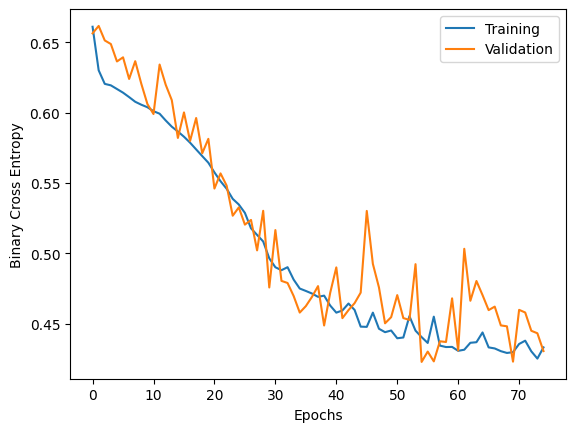

In [17]:
plt.plot(train_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy')
plt.legend()
plt.show()

### Normalize

In [18]:
x_train_min = np.min(x_train, axis=0)
x_train_max = np.max(x_train, axis=0)

x_train = (x_train - x_train_min) / (x_train_max - x_train_min)
x_val = (x_val - x_train_min) / (x_train_max - x_train_min)
x_test = (x_test - x_train_min) / (x_train_max - x_train_min)

train_dataset = TitanicDataset(x_train, y_train)
val_dataset = TitanicDataset(x_val, y_val)
test_dataset = TitanicDataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

### Re-Training

In [19]:
n_epochs = 120
model = ClassificationModel(train_dataset[0][0].shape[0])
loss_fn = nn.BCELoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, loss_fn, n_epochs=n_epochs, delta=0.001, patience=20)

Training 1/120 done, training loss: 0.6646327376365662, validation loss: 0.7071692943572998
Training 2/120 done, training loss: 0.6607831120491028, validation loss: 0.6956582069396973
Training 3/120 done, training loss: 0.6575378775596619, validation loss: 0.7033913731575012
Training 4/120 done, training loss: 0.6538946032524109, validation loss: 0.7047610878944397
Training 5/120 done, training loss: 0.6482384204864502, validation loss: 0.6896727681159973
Training 6/120 done, training loss: 0.6379913091659546, validation loss: 0.6691265106201172
Training 7/120 done, training loss: 0.6242810487747192, validation loss: 0.6480610370635986
Training 8/120 done, training loss: 0.5917166471481323, validation loss: 0.5969579219818115
Training 9/120 done, training loss: 0.5397453904151917, validation loss: 0.527353048324585
Training 10/120 done, training loss: 0.4964280128479004, validation loss: 0.5076059103012085
Training 11/120 done, training loss: 0.4725029170513153, validation loss: 0.4670

### Displayed Normalized Loss

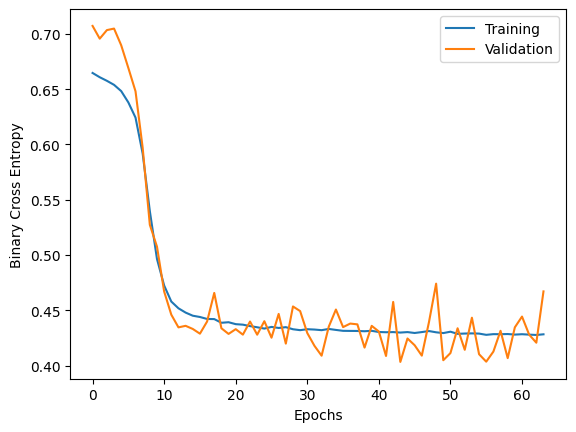

In [20]:
plt.plot(train_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy')
plt.legend()
plt.show()

### Testing

In [21]:
model.eval()
accuracy = []
prediction_label_pairs = []

for x, y in test_dataloader:
    with torch.no_grad():
        y_hat = model(x)
    
    prediction = torch.round(y_hat)
    prediction_label_pairs.append(torch.concat((prediction, y), dim=-1))
    accuracy.append((prediction == y).to(torch.float32))

accuracy = torch.cat(accuracy).mean()
print('Accuracy: ', accuracy.item())
print(prediction_label_pairs[0])

Accuracy:  0.7835820913314819
tensor([[0., 0.],
        [0., 0.],
        [0., 1.],
        [1., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 1.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [0., 0.],
        [1., 1.]])


## Multclass classification

### Read data

In [22]:
glass_data = pd.read_csv('glass.csv')
glass_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [23]:
glass_data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [24]:
features = glass_data.drop(['Type'], axis=1)
target = glass_data['Type'].values.copy()
classes = np.unique(target)
n_class = classes.shape[0]
print(classes)
target[target == 7] = 4
target = np.eye(n_class)[target - 1]
print(target)

[1 2 3 5 6 7]
[[1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]]


### Prepare datasets

In [25]:
x_train, x_rest, y_train, y_rest = train_test_split(features.values, target, train_size=0.7, random_state=4)
x_val, x_test, y_val, y_test = train_test_split(x_rest, y_rest, train_size=0.5, random_state=4)

x_train_min = np.min(x_train, axis=0)
x_train_max = np.max(x_train, axis=0)

x_train = (x_train - x_train_min) / (x_train_max - x_train_min)
x_val = (x_val - x_train_min) / (x_train_max - x_train_min)
x_test = (x_test - x_train_min) / (x_train_max - x_train_min)

class GlassDataset(Dataset):
    def __init__(self, features, target):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.target[index]
    
train_dataset = GlassDataset(x_train, y_train)
val_dataset = GlassDataset(x_val, y_val)
test_dataset = GlassDataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print(train_dataset[11])

(tensor([0.2118, 0.5316, 0.7572, 0.3382, 0.5363, 0.0950, 0.2686, 0.0000, 0.0000]), tensor([0., 0., 1., 0., 0., 0.]))


### Model

In [26]:
class MCClassificationModel(nn.Module):
    def __init__(self, input_dim, n_class) -> None:
        super().__init__()
        self.linear_relu_layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(8, n_class)
        )
    
    def forward(self, x):
        out = self.linear_relu_layers(x)
        return out

In [27]:
class Callback():
    def __init__(self):
        pass

    def on_train_end(self, avg_train_loss):
        pass

    def on_val_end(self, avg_val_loss):
        pass

    def on_test_end(self, avg_test_loss):
        pass

    def on_epoch_end(self, trainer):
        pass

    def on_train_predicition(self, prediction, label):
        pass

    def on_val_prediction(self, prediction, label):
        pass

    def on_test_prediction(self, prediction, label):
        pass

    def on_stop(self, results):
        pass

class EarlyStoppingCallback(Callback):
    def __init__(self, delta=0.01, patience=10, save_path=None, model=None):
        self.delta = delta
        self.patience = patience
        self.best_loss = np.inf
        self.no_improvement_count = 0
        self.save_path = save_path
        self.model = model

    def on_val_end(self, avg_val_loss):
        if avg_val_loss + self.delta < self.best_loss:
            self.best_loss = avg_val_loss
            self.no_improvement_count = 0

            if self.save_path is not None and self.model is not None:
                torch.save(self.model.state_dict(), self.save_path)
        else:
            self.no_improvement_count += 1

    def on_epoch_end(self, trainer):
        if self.no_improvement_count >= self.patience:
            print('Stopped by early stopping')
            print('Best validation loss: ', self.best_loss.item())
            trainer.stop = True

class MetricsCallback(Callback):
    def __init__(self, metrics_to_track):
        self.metrics_to_track = metrics_to_track
        self.__reset()

    def __reset(self):
        self.metrics_temp = dict()
        self.metrics = dict()

    def __add_prediction(self, prediction, label, prefix):
        for metric_name, metric_fn in self.metrics_to_track.items():
            key = f'{prefix}_{metric_name}'
            if key not in self.metrics:
                self.metrics[key] = []
                self.metrics_temp[key] = []
            
            self.metrics_temp[key].append(metric_fn(prediction, label).reshape(-1))

    def __aggregate_metrics(self, prefix):
        for key in self.metrics_to_track.keys():
            self.metrics[f'{prefix}_{key}'].append(torch.cat(self.metrics_temp[f'{prefix}_{key}']).mean().item())
            self.metrics_temp[f'{prefix}_{key}'] = []

    def on_train_predicition(self, prediction, label):
        self.__add_prediction(prediction, label, 'train')

    def on_val_prediction(self, prediction, label):
        self.__add_prediction(prediction, label, 'val')

    def on_test_prediction(self, prediction, label):
        self.__add_prediction(prediction, label, 'test')

    def on_train_end(self, avg_train_loss):
        self.__aggregate_metrics('train')

    def on_val_end(self, avg_val_loss):
        self.__aggregate_metrics('val')

    def on_test_end(self, avg_test_loss):
        self.__aggregate_metrics('test')

    def on_stop(self, results):
        metrics = {key: np.array(val) for key, val in self.metrics.items()}
        results.update(metrics)
        self.__reset()

In [28]:
class Trainer():
    def __init__(self, model, train_dataloader, val_dataloader, optimizer, loss_fn, n_epochs=10, callbacks: list[Callback]=[]):
        self.model = model
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.n_epochs = n_epochs
        self.stop = False
        self.callbacks = callbacks
        self.train_losses = []
        self.val_losses = []

    def __train(self, dataloader):
        self.model.train()
        train_epoch_losses = []

        for x, y in dataloader:
            self.optimizer.zero_grad()
            y_hat = self.model(x)
            loss = self.loss_fn(y_hat, y)
            [callback.on_train_predicition(y_hat.detach(), y) for callback in self.callbacks]
            train_epoch_losses.append(loss)
            loss.backward()
            self.optimizer.step()

        train_epoch_losses = torch.tensor(train_epoch_losses)
        avg_epoch_loss = train_epoch_losses.mean()

        [callback.on_train_end(avg_epoch_loss) for callback in self.callbacks]

        return avg_epoch_loss
    
    def __eval(self, dataloader, test=False):
        self.model.eval()
        epoch_losses = []

        for x, y in dataloader:
            with torch.no_grad():
                y_hat = self.model(x)
            loss = self.loss_fn(y_hat, y)

            if test:
                [callback.on_test_prediction(y_hat.detach(), y) for callback in self.callbacks]
            else:
                [callback.on_val_prediction(y_hat.detach(), y) for callback in self.callbacks]
            
            epoch_losses.append(loss)

        epoch_losses = torch.tensor(epoch_losses)
        avg_epoch_loss = epoch_losses.mean()

        if test:
            [callback.on_test_end(avg_epoch_loss) for callback in self.callbacks]
        else:
            [callback.on_val_end(avg_epoch_loss) for callback in self.callbacks]

        return avg_epoch_loss
    
    def train(self):
        for epoch in range(self.n_epochs):
            train_loss = self.__train(self.train_dataloader)
            self.train_losses.append(train_loss)
            val_loss = self.__eval(self.val_dataloader, test=False)
            self.val_losses.append(val_loss)

            print(f'Training {epoch+1}/{self.n_epochs} don, training loss: {train_loss}, validation loss: {val_loss}')

            [callback.on_epoch_end(self) for callback in self.callbacks]

            if self.stop:
                break

        results = {
            'train_loss': self.train_losses,
            'val_loss': self.val_losses
        }

        [callback.on_stop(results) for callback in self.callbacks]

        return results
    
    def test(self, test_dataloader):
        test_loss = self.__eval(test_dataloader, test=True)

        results = {
            'test_loss': test_loss
        }

        [callback.on_stop(results) for callback in self.callbacks]

        return results


### Training

In [29]:
n_epochs = 200
model = MCClassificationModel(train_dataset[0][0].shape[0], n_class=n_class)
loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

def accuracy(pred, label):
    pred = torch.argmax(pred, dim=-1)
    label = torch.argmax(label, dim=-1)

    return (pred == label).to(torch.float32)

metrics = {
    'Accuracy': accuracy
}

earlystopping_callback = EarlyStoppingCallback(delta=0.01, patience=20, save_path='best_model2.pth', model=model)
metrics_callback = MetricsCallback(metrics)
callbacks = [earlystopping_callback, metrics_callback]
trainer = Trainer(model, train_dataloader, val_dataloader, optimizer, loss_fn, n_epochs=400, callbacks=callbacks)
results = trainer.train()

Training 1/400 don, training loss: 1.9879812002182007, validation loss: 1.9802589416503906
Training 2/400 don, training loss: 1.9587018489837646, validation loss: 1.9557034969329834
Training 3/400 don, training loss: 1.9483623504638672, validation loss: 1.932711124420166
Training 4/400 don, training loss: 1.9182837009429932, validation loss: 1.914726972579956
Training 5/400 don, training loss: 1.9012781381607056, validation loss: 1.9018818140029907
Training 6/400 don, training loss: 1.8931617736816406, validation loss: 1.8859634399414062
Training 7/400 don, training loss: 1.8758920431137085, validation loss: 1.870530128479004
Training 8/400 don, training loss: 1.8609365224838257, validation loss: 1.8531140089035034
Training 9/400 don, training loss: 1.8569787740707397, validation loss: 1.832873821258545
Training 10/400 don, training loss: 1.8331234455108643, validation loss: 1.8091628551483154
Training 11/400 don, training loss: 1.8108570575714111, validation loss: 1.781038761138916
Tr

### Visualize Results

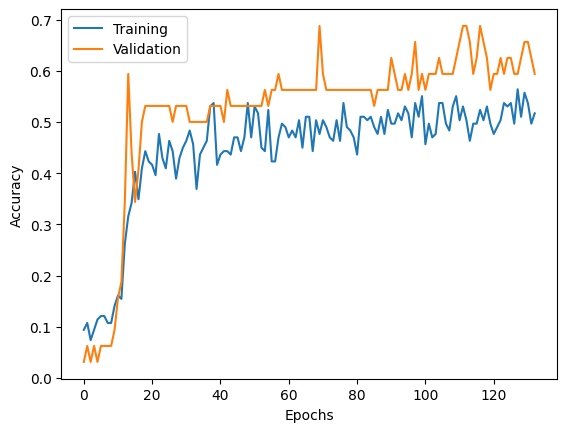

In [30]:
plt.plot(results['train_Accuracy'], label='Training')
plt.plot(results['val_Accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Testing

In [31]:
model.eval()
accuracy = []
prediction_label_pairs = []

for x, y in test_dataloader:
    with torch.no_grad():
        y_hat = model(x)
    prediction = torch.argmax(y_hat, dim=1)
    y = torch.argmax(y, dim=1)
    prediction_label_pairs.append(torch.stack((prediction, y), dim=1))
    accuracy.append((prediction==y).to(torch.float32))

accuracy = torch.cat(accuracy).mean()
print('Accuracy: ', accuracy.item())
print(prediction_label_pairs[0])
print(trainer.test(test_dataloader))

Accuracy:  0.7272727489471436
tensor([[3, 3],
        [1, 1],
        [0, 0],
        [0, 0],
        [1, 1],
        [0, 0],
        [0, 0],
        [3, 3],
        [1, 5],
        [0, 1],
        [1, 4],
        [0, 0],
        [0, 1],
        [0, 0],
        [3, 3],
        [0, 0]])
{'test_loss': tensor(0.8826), 'test_Accuracy': array([0.72727275])}


### Confusion Matrix

In [32]:
from sklearn.metrics import confusion_matrix

prediction_label_pairs = torch.cat(prediction_label_pairs, 0)
print(prediction_label_pairs.shape)
conf = confusion_matrix(prediction_label_pairs[:,1], prediction_label_pairs[:,0])

torch.Size([33, 2])


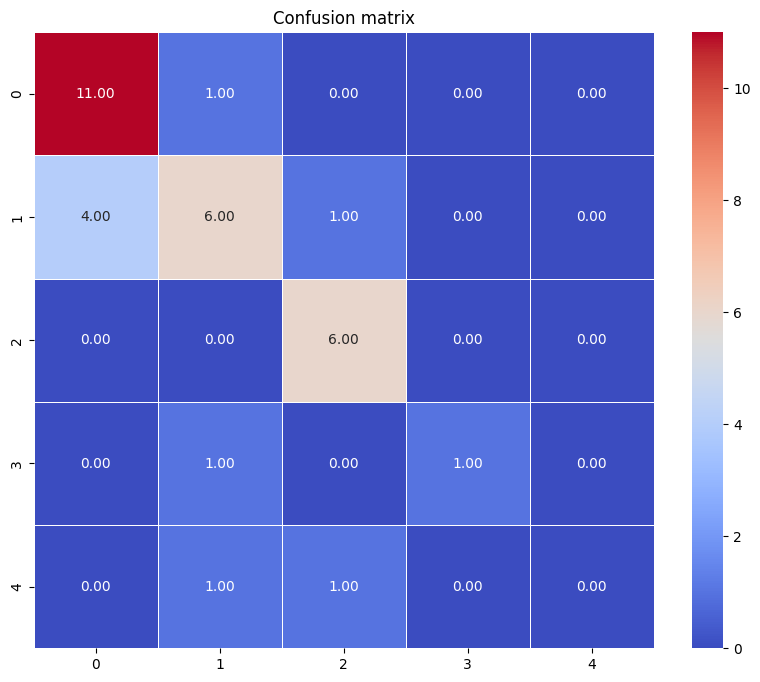

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(conf,annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Confusion matrix')
plt.show()